<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Goal" data-toc-modified-id="Goal-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Goal</a></span></li><li><span><a href="#Var" data-toc-modified-id="Var-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var</a></span></li><li><span><a href="#Init" data-toc-modified-id="Init-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Init</a></span></li><li><span><a href="#Load" data-toc-modified-id="Load-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Load</a></span><ul class="toc-item"><li><span><a href="#Checks" data-toc-modified-id="Checks-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Checks</a></span></li></ul></li><li><span><a href="#FD" data-toc-modified-id="FD-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>FD</a></span><ul class="toc-item"><li><span><a href="#w/-dim-redunction" data-toc-modified-id="w/-dim-redunction-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>w/ dim-redunction</a></span><ul class="toc-item"><li><span><a href="#Saving" data-toc-modified-id="Saving-5.1.1"><span class="toc-item-num">5.1.1&nbsp;&nbsp;</span>Saving</a></span></li><li><span><a href="#Formatting" data-toc-modified-id="Formatting-5.1.2"><span class="toc-item-num">5.1.2&nbsp;&nbsp;</span>Formatting</a></span></li><li><span><a href="#Summary" data-toc-modified-id="Summary-5.1.3"><span class="toc-item-num">5.1.3&nbsp;&nbsp;</span>Summary</a></span></li><li><span><a href="#Mixed-effects-models" data-toc-modified-id="Mixed-effects-models-5.1.4"><span class="toc-item-num">5.1.4&nbsp;&nbsp;</span>Mixed effects models</a></span><ul class="toc-item"><li><span><a href="#Full-dataset" data-toc-modified-id="Full-dataset-5.1.4.1"><span class="toc-item-num">5.1.4.1&nbsp;&nbsp;</span>Full dataset</a></span></li><li><span><a href="#Westernized-+-gender" data-toc-modified-id="Westernized-+-gender-5.1.4.2"><span class="toc-item-num">5.1.4.2&nbsp;&nbsp;</span>Westernized + gender</a></span></li><li><span><a href="#westernized-+-gender-+-age" data-toc-modified-id="westernized-+-gender-+-age-5.1.4.3"><span class="toc-item-num">5.1.4.3&nbsp;&nbsp;</span>westernized + gender + age</a></span></li><li><span><a href="#westernized-+-gender-+-age-+-bmi" data-toc-modified-id="westernized-+-gender-+-age-+-bmi-5.1.4.4"><span class="toc-item-num">5.1.4.4&nbsp;&nbsp;</span>westernized + gender + age + bmi</a></span></li><li><span><a href="#westernized-+-gender-+-age-+-disease" data-toc-modified-id="westernized-+-gender-+-age-+-disease-5.1.4.5"><span class="toc-item-num">5.1.4.5&nbsp;&nbsp;</span>westernized + gender + age + disease</a></span></li><li><span><a href="#Summary:-w/-BMI" data-toc-modified-id="Summary:-w/-BMI-5.1.4.6"><span class="toc-item-num">5.1.4.6&nbsp;&nbsp;</span>Summary: w/ BMI</a></span></li><li><span><a href="#Summary:-w/-disease" data-toc-modified-id="Summary:-w/-disease-5.1.4.7"><span class="toc-item-num">5.1.4.7&nbsp;&nbsp;</span>Summary: w/ disease</a></span></li></ul></li></ul></li><li><span><a href="#All-traits" data-toc-modified-id="All-traits-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>All traits</a></span><ul class="toc-item"><li><span><a href="#Saving" data-toc-modified-id="Saving-5.2.1"><span class="toc-item-num">5.2.1&nbsp;&nbsp;</span>Saving</a></span></li></ul></li></ul></li><li><span><a href="#sessionInfo" data-toc-modified-id="sessionInfo-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>sessionInfo</a></span></li></ul></div>

# Goal

* Calculate functional diversity across all samples
* Measures of function:
  * Traitar phenotypes

# Var

In [1]:
# working dir
work_dir = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/'

# bracken counts
brk_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/bracken_filt.qs'

# GTDBr89 genome metadata
genome_meta_file = '/ebio/abt3_projects/databases_no-backup/GTDB/release89/LLMGP-DB/metadata_1per-GTDB-Spec_gte50comp-lt5cont_wtaxID_wPath.tsv'

# sample metadata
## filtered
metadata_filt_file = file.path(work_dir, 'CurMetDat_metadata_filt-n1846.tsv')
## all 
base_in_dir = '/ebio/abt3_projects/small_projects/nyoungblut/public_data_retireval/'
metadata_file = file.path(base_in_dir, 'CurMetDat-metagenomes', 'files', 'metadata', 'Filtered_CurMetDat_f.tsv')

# trees
## GTDB phylogeny
phy_file = '/ebio/abt3_projects/databases_no-backup/GTDB/release89/LLMGP-DB/phylogeny/ar122-bac120_r89_1per-GTDB-Spec_gte50comp-lt5cont_rn.nwk'
## trait phylogeny
phy_trt_file = '/ebio/abt3_projects/databases_no-backup/GTDB/release89/LLMGP-DB/genomes/LLG//phenotype/predictions_flat_majority-votes_combined_jaccard_rn.nwk'

# Traitar traits
F = '/ebio/abt3_projects/databases_no-backup/GTDB/release89/LLMGP-DB/genomes/LLG/'
traitar_maj_vote_file = file.path(F, 'phenotype', 'predictions_flat_majority-votes_combined.tsv.gz')

# params
threads = 8
my_seed = 68372

# Init

In [2]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(tidytable)
library(ape)
library(FD)
library(LeyLabRMisc)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last



Attaching package: ‘tidytable’


The following object is masked from ‘package:stats’:

    dt


Loading required package: ade4

Loading required package: geometry

Loading required package: vegan

Loading required package: permute

Loading required package: lattice

This is vegan 2.5-7



In [3]:
df.dims()
setDTthreads(threads)
make_dir(work_dir)

Directory already exists: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ 


# Load

In [4]:
# sample metadata
meta = Fread(metadata_file) %>%
    mutate.(Sample = gsub('-', '.', Sample)) %>%
    filter.(number_reads >= 5e5)
meta

dataset_name,Sample,subjectID,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
AsnicarF_2017,MV_FEM1_t1Q14,MV_FEM1,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
AsnicarF_2017,MV_FEM2_t1Q14,MV_FEM2,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
ZellerG_2014,CCIS82944710ST.20.0,FR-730,stool,NA,control,healthy,38,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
ZellerG_2014,CCIS93040568ST.20.0,FR-682,stool,NA,control,healthy,65,adult,male,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


In [5]:
# Bracken count table
brk = qs::qread(brk_file, nthreads=threads) %>%
    mutate.(name = gsub(' ', '_', name))
brk 

dataset,name,taxonomy_id,taxonomy_lvl,Domain,Phylum,Class,Order,Family,Genus,Species,Sample,Abundance
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CosteaPI_2017,s__Caecibacter_massiliensis,108259,S,Bacteria,Firmicutes_C,Negativicutes,Veillonellales,Megasphaeraceae,Caecibacter,Caecibacter massiliensis,halbarad.11.0.0,0
CosteaPI_2017,s__UBA1777_sp002350825,178550,S,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,UBA1777,UBA1777 sp002350825,halbarad.11.0.0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YuJ_2015,s__Serratia_grimesii,121568,S,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia grimesii,SZAXPI017592.142,0
YuJ_2015,s__Bacteroides_A_sp002161565,119189,S,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides_A,Bacteroides_A sp002161565,SZAXPI017592.142,0


In [6]:
# trees
## genome phylogeny
gtdb_phy = read.tree(phy_file)
gtdb_phy
## trait dendrogram
trt_phy = read.tree(phy_trt_file)
trt_phy


Phylogenetic tree with 23360 tips and 23359 internal nodes.

Tip labels:
  s__Halorubrum_sp000296615, s__Halorubrum_distributum, s__Halorubrum_trapanicum, s__Halorubrum_tropicale, s__Halorubrum_coriense, s__Halorubrum_ezzemoulense, ...
Node labels:
  100.0, d__Archaea100.0, 97.0, 99.0, 100.0, 100.0-p__Halobacterota, ...

Rooted; includes branch lengths.


Phylogenetic tree with 23360 tips and 23359 internal nodes.

Tip labels:
  s__Mikella_endobia, s__Prochlorococcus_B_sp003284185, s__Prochlorococcus_A_sp003282425, s__Eperythrozoon_A_wenyonii_A, s__GN02-872_sp003260325, s__SZUA-486_sp003251635, ...

Rooted; includes branch lengths.

In [7]:
# traits
cmd = glue::glue('gunzip -c {file}', file=traitar_maj_vote_file)
trt_maj_votes = Fread(cmd=cmd) %>%
    filter.(phenotype_model == 'phypat+PGL')
trt_maj_votes

sample,phenotype,prediction,phenotype_model
<chr>,<chr>,<int>,<chr>
GCA_002287175.1,Growth on ordinary blood agar,1,phypat+PGL
GCA_002287175.1,Sucrose,1,phypat+PGL
⋮,⋮,⋮,⋮
GCA_003234965.1,Trehalose,0,phypat+PGL
GCA_003234965.1,Yellow pigment,0,phypat+PGL


In [8]:
# genome metadata
# metadata
tax_levs = c('Domain', 'Phylum', 'Class', 'Order', 'Family', 'Genus', 'Species')
g_meta = Fread(genome_meta_file) %>%
    select.(ncbi_genbank_assembly_accession, ncbi_organism_name, gtdb_taxonomy, accession) %>%
    rename.('GTDB_accession' = accession) %>%
    separate.(gtdb_taxonomy, tax_levs, sep=';')

g_meta %>% unique_n('accessions', ncbi_genbank_assembly_accession)
g_meta

No. of unique accessions: 23360 


ncbi_genbank_assembly_accession,ncbi_organism_name,GTDB_accession,Domain,Phylum,Class,Order,Family,Genus,Species
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
GCA_002789635.1,GB_GCA_002789635.1_Candidatus Aenigmarchaeota archaeon CG_4_9_14_3_um_filter_37_18,GB_GCA_002789635.1,d__Archaea,p__Aenigmarchaeota,c__Aenigmarchaeia,o__CG10238-14,f__CG10238-14,g__CG10238-14,s__CG10238-14 sp002789635
GCA_001784635.1,GB_GCA_001784635.1_Candidatus Micrarchaeota archaeon RBG_16_49_10,GB_GCA_001784635.1,d__Archaea,p__Aenigmarchaeota,c__Aenigmarchaeia,o__CG10238-14,f__CG10238-14,g__RBG-16-49-10,s__RBG-16-49-10 sp001784635
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
GCA_001775395.1,GB_GCA_001775395.1_candidate division Zixibacteria bacterium RBG_16_53_22,GB_GCA_001775395.1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UBA10806,f__UBA10806,g__UBA10806,s__UBA10806 sp001775395
GCA_002791595.1,GB_GCA_002791595.1_candidate division Zixibacteria bacterium CG_4_9_14_3_um_filter_46_8,GB_GCA_002791595.1,d__Bacteria,p__Zixibacteria,c__MSB-5A5,o__UM-FILTER-46-8,f__UM-FILTER-46-8,g__UM-FILTER-46-8,s__UM-FILTER-46-8 sp002791595


## Checks

In [9]:
# checking overlap of genome metadata & phenotype data
overlap(trt_maj_votes, g_meta, sample, ncbi_genbank_assembly_accession)

intersect(x,y): 22837 
setdiff(x,y): 0 
setdiff(y,x): 523 
union(x,y): 23360 


In [10]:
# adding species & converting to wide table
trt = trt_maj_votes %>%
    inner_join.(g_meta %>% select.(ncbi_genbank_assembly_accession, Species), 
                by=c('sample'='ncbi_genbank_assembly_accession')) %>%
    mutate.(Species = gsub(' ', '_', Species)) %>%
    select.(Species, phenotype, prediction) %>%
    pivot_wider.(phenotype, prediction) %>%
    as.data.frame
rownames(trt) = trt$Species
trt$Species = NULL
trt

,Acetate utilization,Aerobe,Alkaline phosphatase,Anaerobe,Arginine dihydrolase,Bacillus or coccobacillus,Beta hemolysis,Bile-susceptible,Capnophilic,Casein hydrolysis,⋯,Salicin,Spore formation,Starch hydrolysis,Sucrose,Tartrate utilization,Trehalose,Urea hydrolysis,Voges Proskauer,Yellow pigment,myo-Inositol
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
s__0-14-0-10-38-17_sp002774085,0,0,0,0,1,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
s__0-14-0-20-34-12_sp002779065,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
s__Zymomonas_mobilis,0,1,0,0,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
s__Zymomonas_pomaceae,0,1,0,0,0,1,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [11]:
# coverting counts table to wide matrix
m = brk %>%
    select.(Sample, name, Abundance) %>%
    mutate.(name = gsub(' ', '_', name)) %>%
    pivot_wider.(name, Abundance) %>%
    mutate_across.(is.numeric, 
                   function(x) ifelse(is.na(x), 0, x)) %>%
    as.data.frame
rownames(m) = m$Sample
m$Sample = NULL
m

Warning message:
“Predicate functions must be wrapped in `where()`.

  # Bad
  data %>% select(is.numeric)

  # Good
  data %>% select(where(is.numeric))

ℹ Please update your code.
This message is displayed once per session.”


,s__1-14-0-10-34-76_sp002763075,s__1-19_sp001922585,s__14-2_sp000403255,s__14-2_sp000403315,s__14-2_sp000403845,s__14-2_sp001940225,s__2-01-FULL-39-21_sp001792305,s__2013-40CM-41-45_sp002215675,s__46-32_sp003243445,s__51-20_sp001917175,⋯,s__Zag111_sp002405805,s__Zag111_sp002438405,s__Zag111_sp003258735,s__Zag1_sp000433095,s__Zag1_sp000437435,s__Zag1_sp000438175,s__Zag1_sp001765415,s__Zag1_sp001917115,s__Zoogloea_sp002028455,s__Zunongwangia_mangrovi
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,0,0,0.00000,0,0,0
A02_01_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,0.00036,0,0,0,0,0.00038,0,0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,0,0,0,0,0,0e+00,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
scavenger.11.60.0,0,0,0,0,0,3e-04,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [12]:
# checking overlap
overlap(colnames(m), rownames(trt))

intersect(x,y): 3541 
setdiff(x,y): 9 
setdiff(y,x): 19296 
union(x,y): 22846 


In [13]:
# filtering to just overlapping
x = intersect(colnames(m), rownames(trt))
trt = trt[x,]
#m = m[1:100,x]
m = m[,x]
overlap(colnames(m), rownames(trt))

intersect(x,y): 3541 
setdiff(x,y): 0 
setdiff(y,x): 0 
union(x,y): 3541 


In [14]:
# filtering by abundance
m = m[,colSums(m) > 0]
x = intersect(colnames(m), rownames(trt))
trt = trt[x,]
overlap(colnames(m), rownames(trt))

intersect(x,y): 3541 
setdiff(x,y): 0 
setdiff(y,x): 0 
union(x,y): 3541 


In [15]:
# checking dimensions
trt %>% dim
m %>% dim

[1] 3541   67

[1] 3357 3541

# FD

## w/ dim-redunction

In [ ]:
# FD
## WARNING: VERY SLOW
FD_res = dbFD(trt, m, corr="cailliez", m='min', calc.CWM=FALSE)
FD_res %>% names

Warning message in is.euclid(x.dist):
“Zero distance(s)”
Warning message in is.euclid(x.dist):
“Zero distance(s)”


FRic: Dimensionality reduction was required. The last 64 PCoA axes (out of 67 in total) were removed. 


Warning message in is.euclid(x.dist):
“Zero distance(s)”


FRic: Quality of the reduced-space representation = 0.3386984 


Warning message in is.euclid(x.dist):
“Zero distance(s)”
Warning message in is.euclid(x.dist):
“Zero distance(s)”


### Saving

In [16]:
# saving: outfile
outfile = file.path(work_dir, 'Traitar_FD_m-min.RDS')
outfile

[1] "/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity//Traitar_FD_m-min.RDS"

In [ ]:
# saving: save
# WARNING!
saveRDS(FD_res, outfile)
cat('File written:', outfile, '\n')

In [17]:
# saving: re-loading
FD_res = readRDS(outfile)
FD_res %>% names

[1] "nbsp"      "sing.sp"   "FRic"      "qual.FRic" "FEve"      "FDiv"     
[7] "FDis"      "RaoQ"

In [ ]:
send_email('http://127.0.0.1:9701/notebooks/ipynb/02_comm_diversity/10_func-div.ipynb')

### Formatting

In [18]:
v = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
FD_res_df = v %>%
    lapply(function(x) FD_res[[x]] %>% as.data.frame) %>%
    do.call(cbind, .)
           
colnames(FD_res_df) = c('FRic', 'FEve', 'FDiv', 'FDis', 'RaoQ') 
FD_res_df

,FRic,FEve,FDiv,FDis,RaoQ
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,405.3489,0.6305880,0.7290097,6.973794,52.75731
A02_01_1FE,315.4350,0.5794583,0.8070891,6.341048,45.50104
⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,243.02318,0.5773991,0.8391111,5.956270,37.65335
scavenger.11.60.0,99.81046,0.5403505,0.5274329,5.515369,31.73968


In [19]:
# adding sample metadata
FD_res_df = FD_res_df %>%
    tibble::rownames_to_column('Sample') %>%
    inner_join(meta, c('Sample'))
FD_res_df

Sample,FRic,FEve,FDiv,FDis,RaoQ,dataset_name,subjectID,body_site,antibiotics_current_use,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
A01_02_1FE,405.3489,0.6305880,0.7290097,6.973794,52.75731,PasolliE_2018,A01_02_1FE,stool,no,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,FALSE
A02_01_1FE,315.4350,0.5794583,0.8070891,6.341048,45.50104,PasolliE_2018,A02_01_1FE,stool,no,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,FALSE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,243.02318,0.5773991,0.8391111,5.956270,37.65335,LiJ_2017,nHMX11726,stool,no,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
scavenger.11.60.0,99.81046,0.5403505,0.5274329,5.515369,31.73968,CosteaPI_2017,DEU26,stool,NA,⋯,NA,NA,NA,NA,NA,NA,NA,4,1,TRUE


### Summary

In [20]:
# formatting
FD_res_df_f = FD_res_df %>%
    dplyr::select(FRic, FEve, FDiv, FDis, RaoQ, Sample, westernized, age, gender,
                  BMI, study_condition, disease, dataset_name) %>%
    pivot_longer(c(FRic, FEve, FDiv, FDis, RaoQ), names_to='measure')
FD_res_df_f

Sample,westernized,age,gender,BMI,study_condition,disease,dataset_name,measure,value
<chr>,<lgl>,<int>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
A01_02_1FE,FALSE,NA,NA,NA,control,healthy,PasolliE_2018,FRic,405.348925
A01_02_1FE,FALSE,NA,NA,NA,control,healthy,PasolliE_2018,FEve,0.630588
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
scavenger.11.60.0,TRUE,NA,NA,NA,control,healthy,CosteaPI_2017,FDis,5.515369
scavenger.11.60.0,TRUE,NA,NA,NA,control,healthy,CosteaPI_2017,RaoQ,31.739685


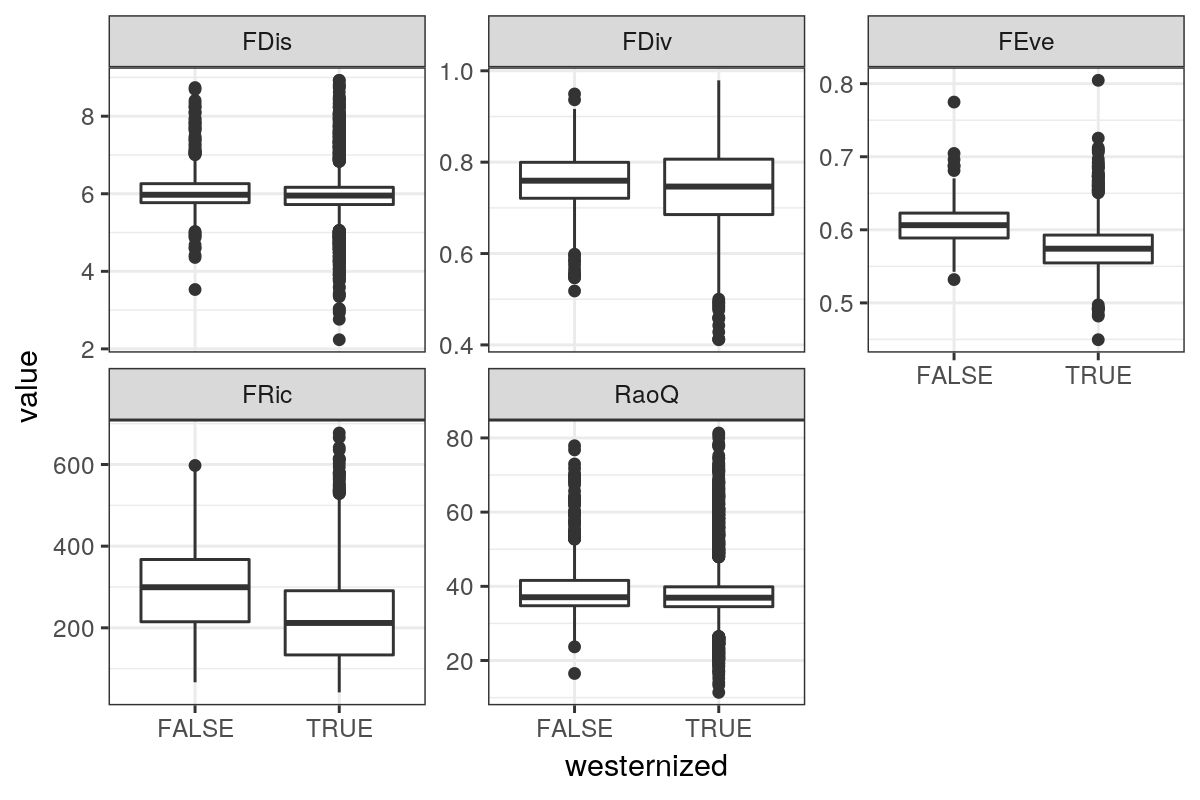

In [21]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(westernized, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(6,4)
plot(p)

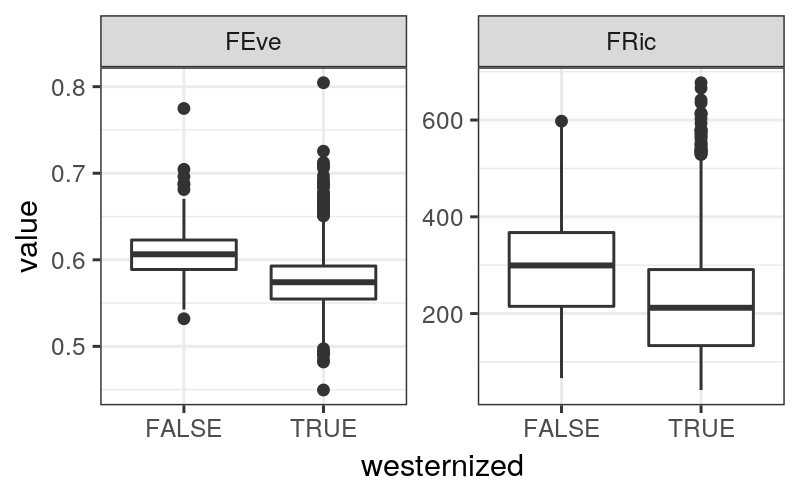

In [22]:
# plotting
p = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    ggplot(aes(westernized, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(4,2.5)
plot(p)

`geom_smooth()` using formula 'y ~ x'

Warning message:
“Removed 7095 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 7095 rows containing missing values (geom_point).”


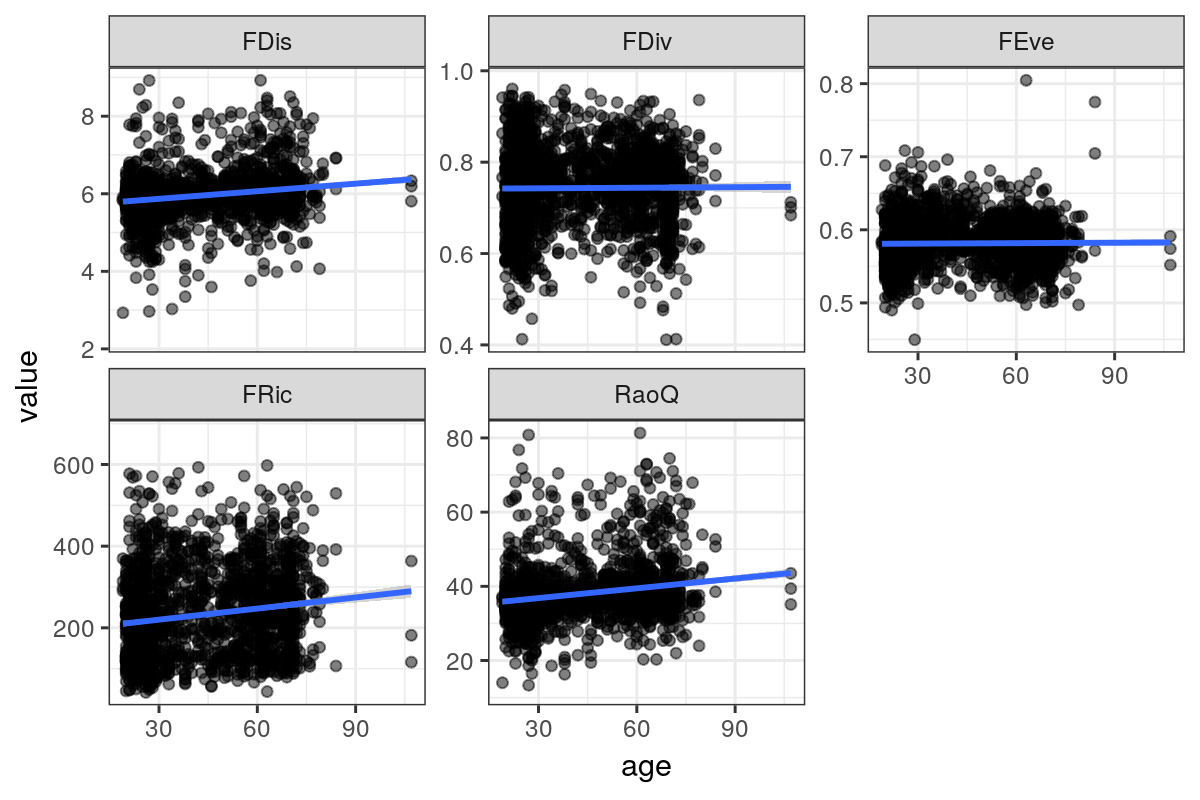

In [23]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(age, value)) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(6,4)
plot(p)

`geom_smooth()` using formula 'y ~ x'



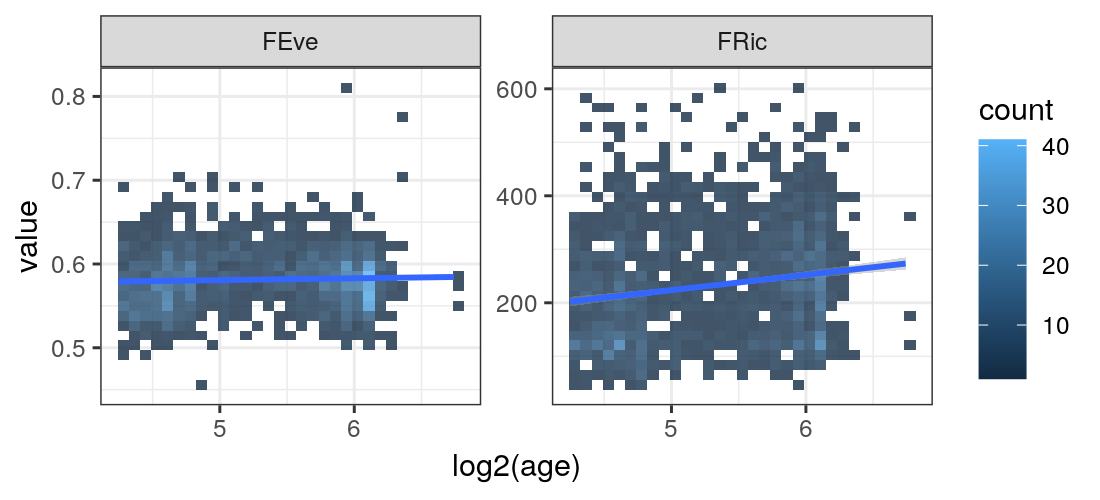

In [24]:
# plotting
p = FD_res_df_f %>%
    filter(!is.na(age)) %>%
    mutate(age = log2(age)) %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    ggplot(aes(age, value)) +
    geom_bin2d(alpha=0.8) +
    geom_smooth(method='lm') +
    labs(x='log2(age)') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(5.5,2.5)
plot(p)

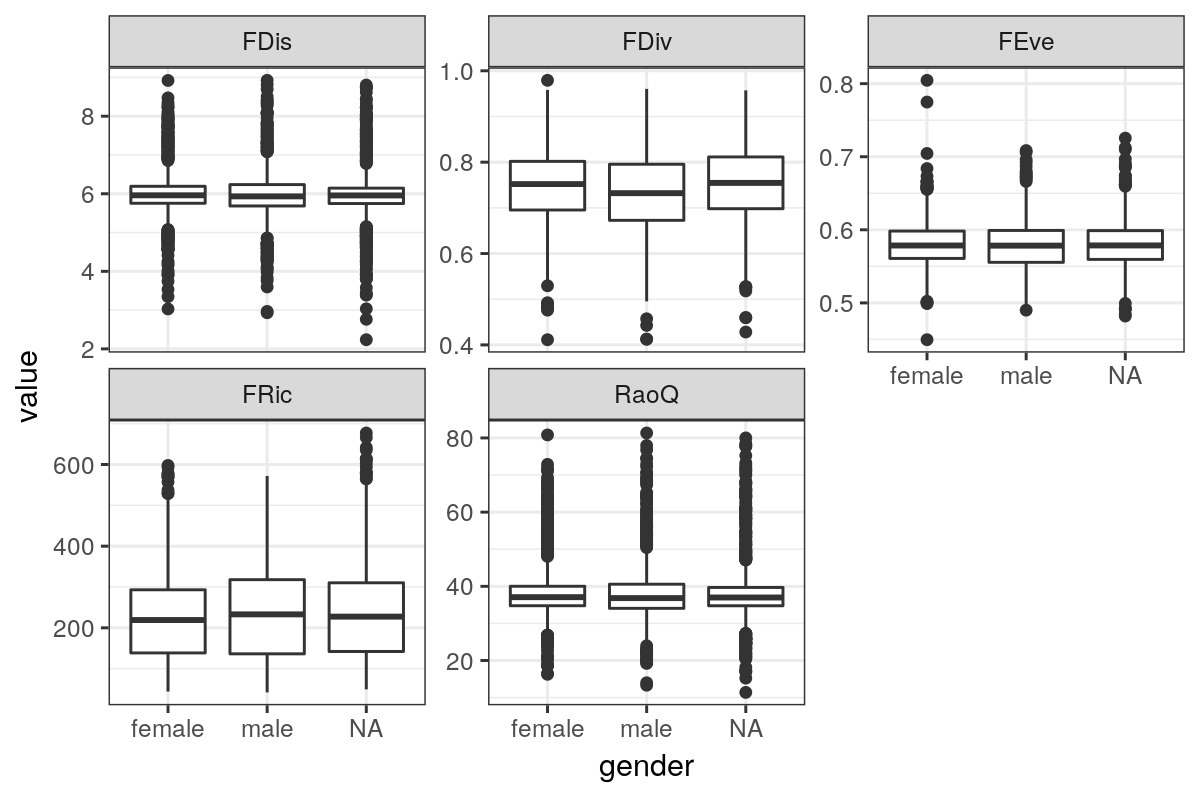

In [25]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(gender, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(6,4)
plot(p)

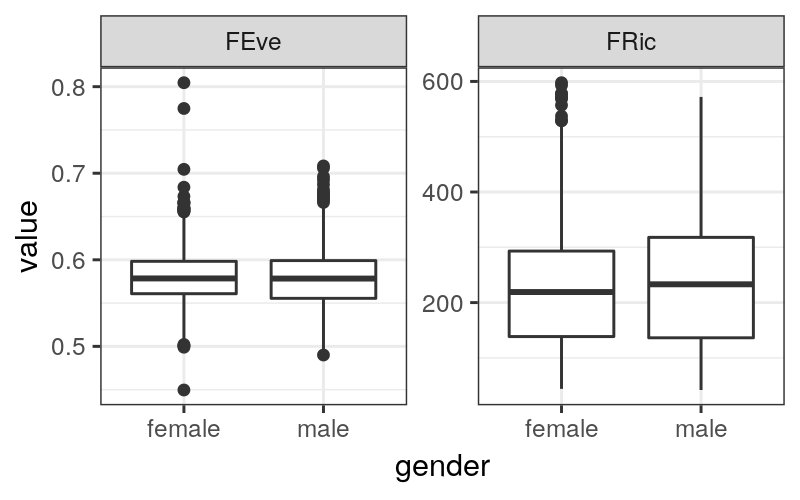

In [26]:
# plotting
p = FD_res_df_f %>%
    filter(!is.na(gender)) %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    ggplot(aes(gender, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(4,2.5)
plot(p)

Warning message:
“Removed 10605 rows containing missing values (geom_point).”


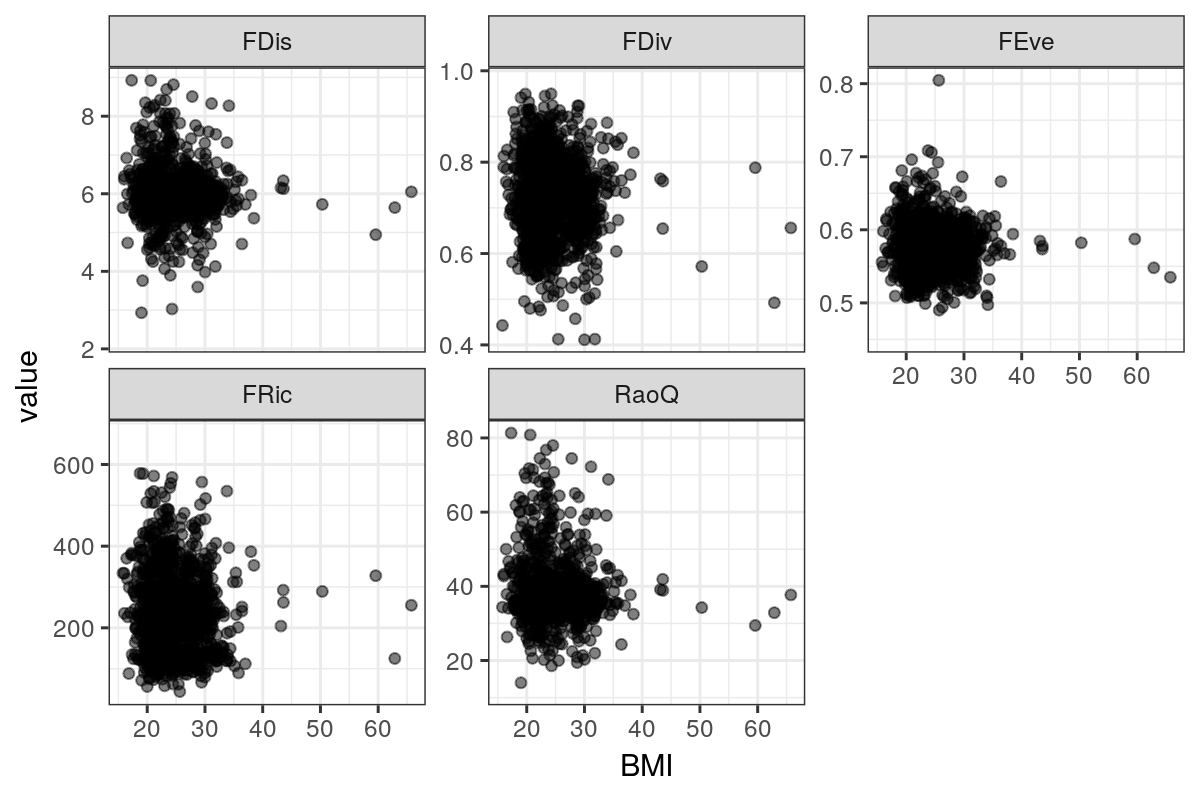

In [27]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(BMI, value)) +
    geom_point(alpha=0.5) +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(6,4)
plot(p)

`geom_smooth()` using formula 'y ~ x'

Warning message:
“Removed 4242 rows containing non-finite values (stat_smooth).”
Warning message:
“Removed 4242 rows containing missing values (geom_point).”


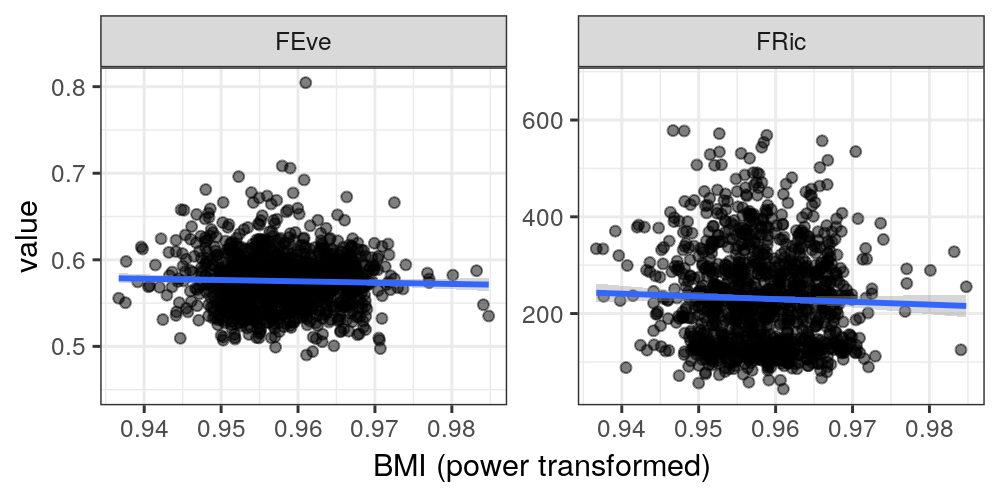

In [28]:
# plotting
p = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    mutate(BMI = car::bcPower(BMI, -1)) %>%
    ggplot(aes(BMI, value)) +
    geom_point(alpha=0.5) +
    geom_smooth(method='lm') +
    labs(x='BMI (power transformed)') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw()

p.dims(5,2.5)
plot(p)

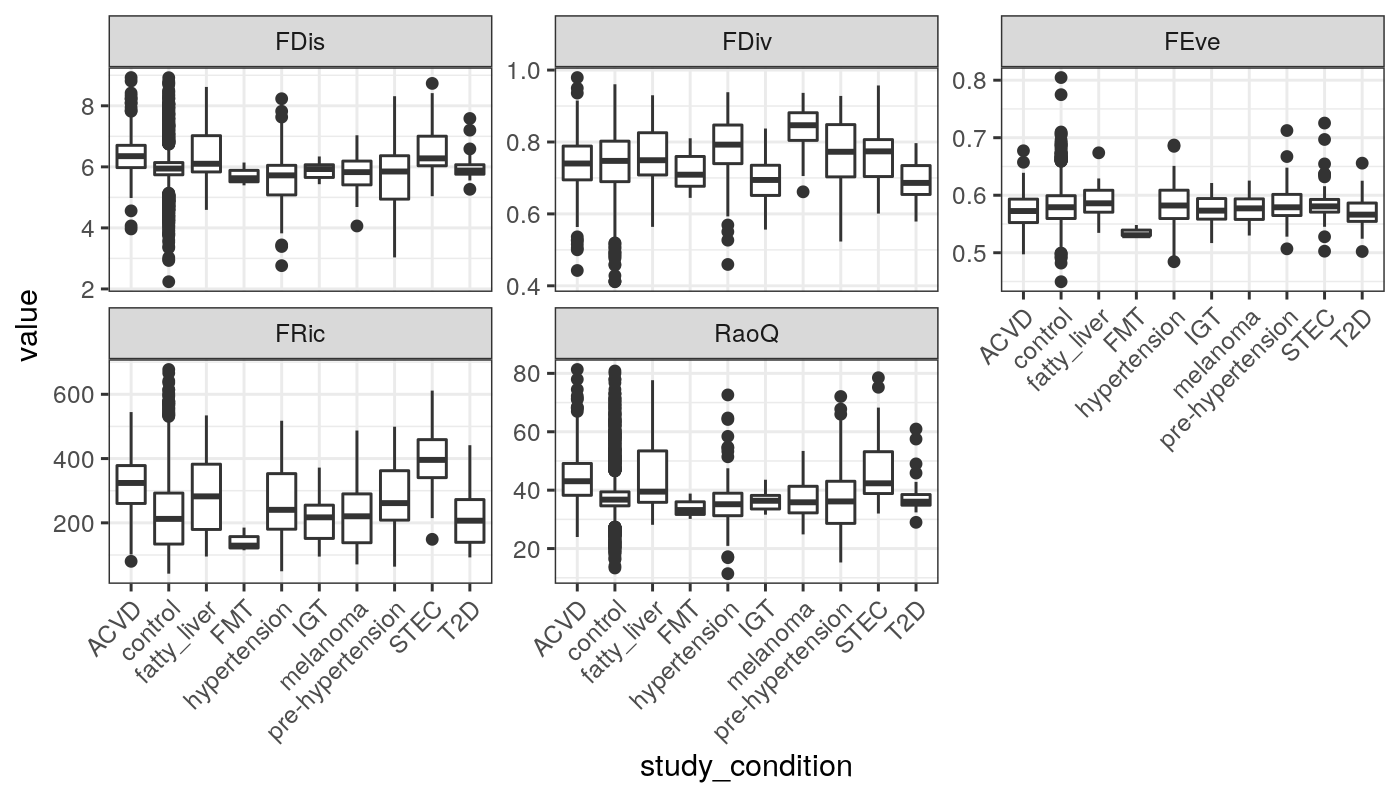

In [29]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(study_condition, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(7,4)
plot(p)

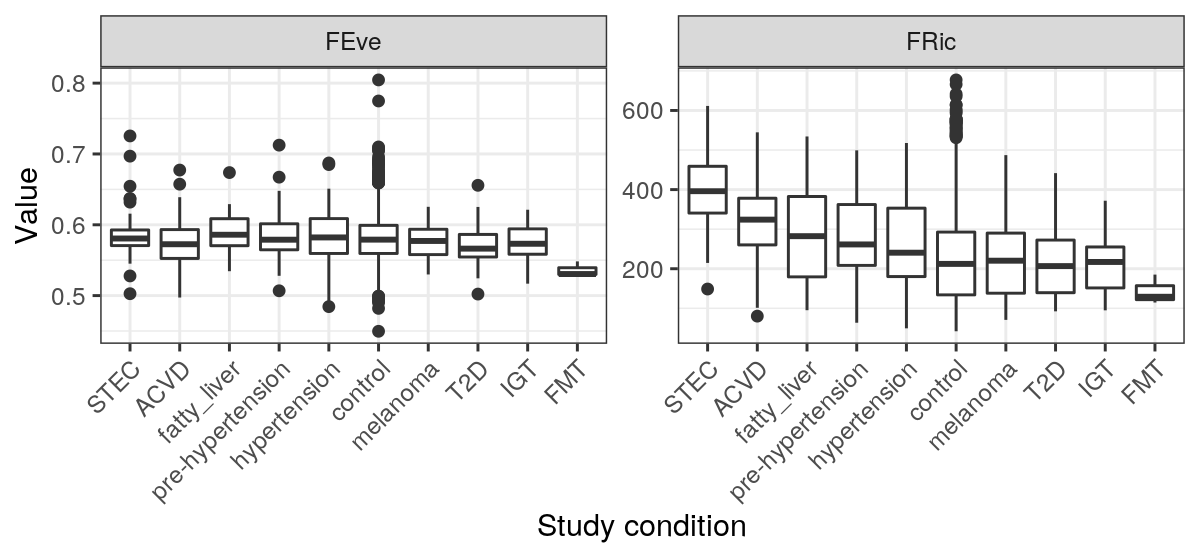

In [30]:
# plotting
func = function(x) mean(-x)
p = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    mutate(study_condition = study_condition %>% reorder(value, func)) %>%
    ggplot(aes(study_condition, value)) +
    geom_boxplot() +
    labs(x='Study condition', y='Value') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(6,2.8)
plot(p)

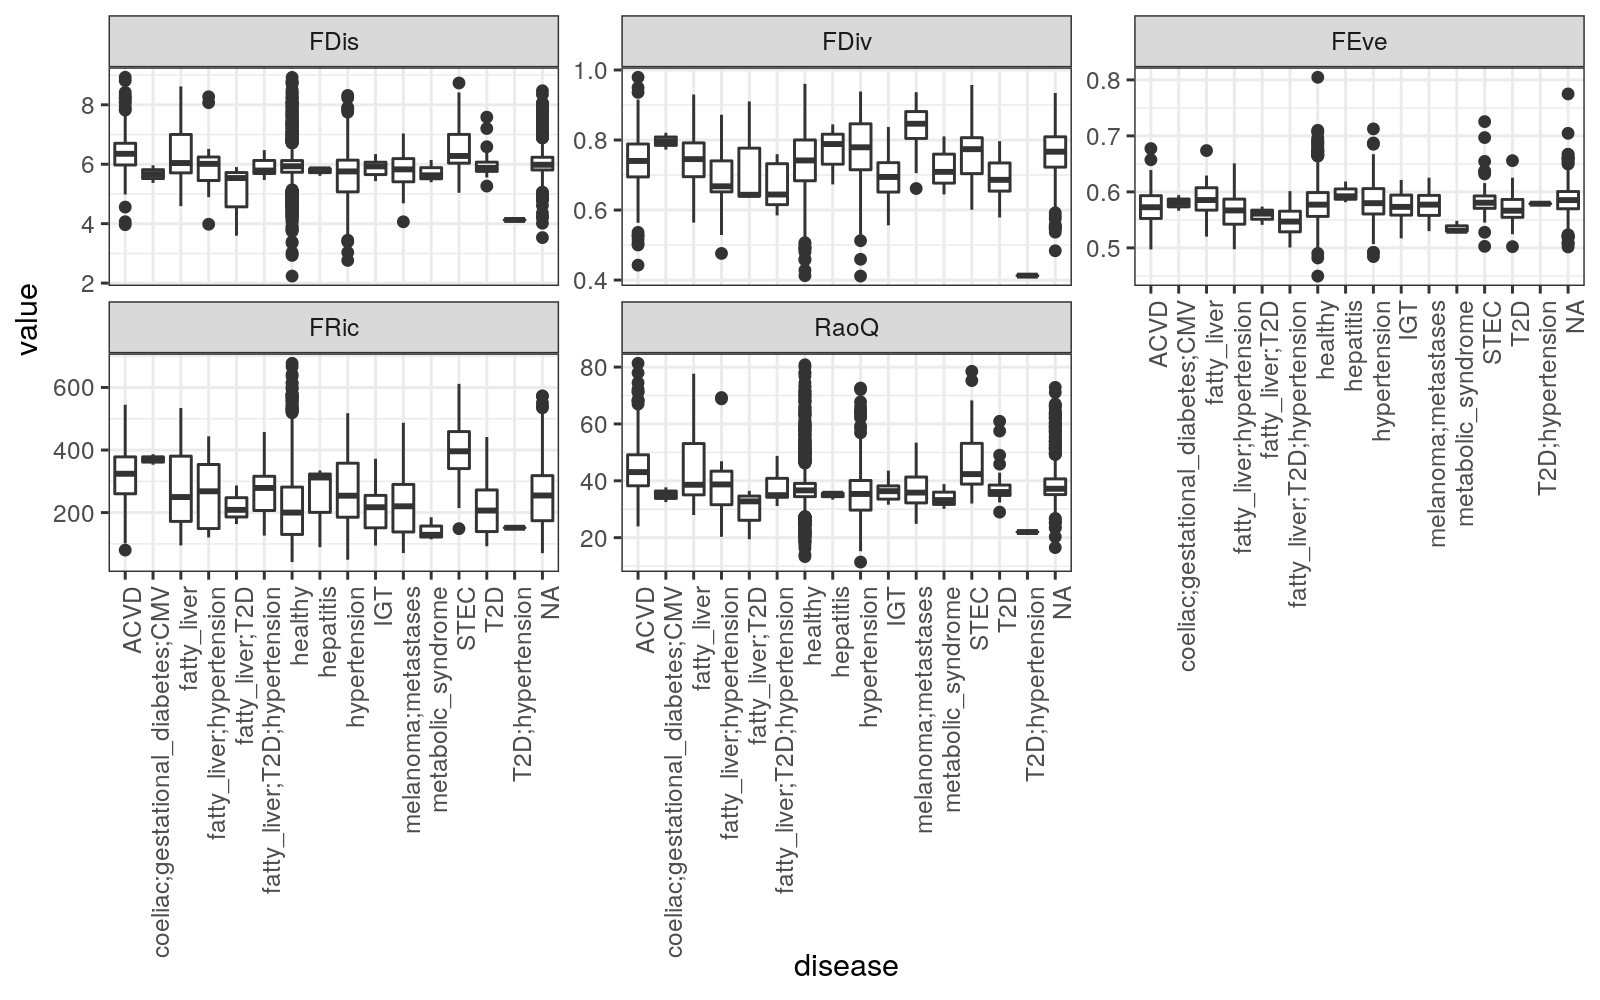

In [31]:
# plotting
p = FD_res_df_f %>%
    ggplot(aes(disease, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=90, hjust=1, vjust=0.9)
    )

p.dims(8,5)
plot(p)

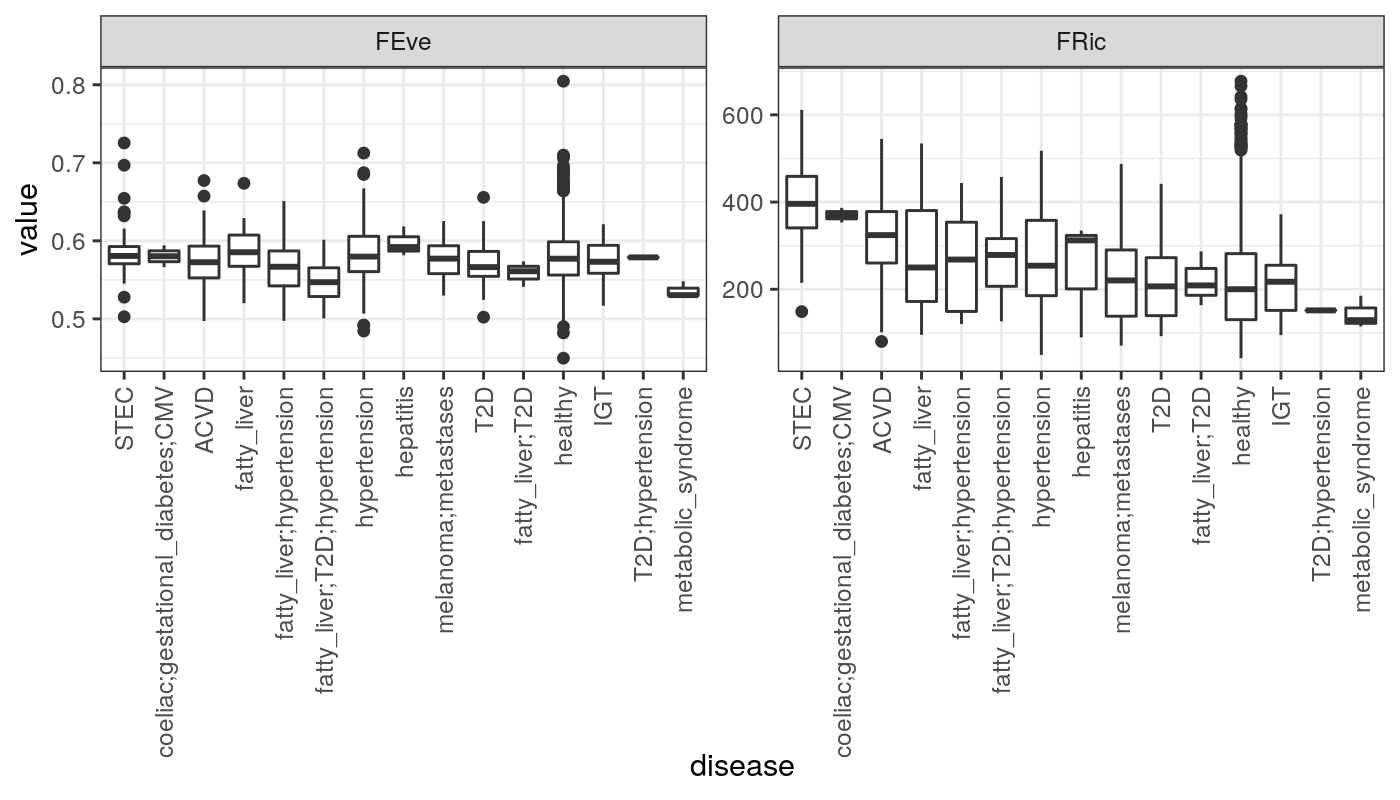

In [32]:
# plotting
func = function(x) mean(-x)
p = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    filter(!is.na(disease)) %>%
    mutate(disease = disease %>% reorder(value, func)) %>%
    ggplot(aes(disease, value)) +
    geom_boxplot() +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=90, hjust=1, vjust=0.5)
    )

p.dims(7,4)
plot(p)

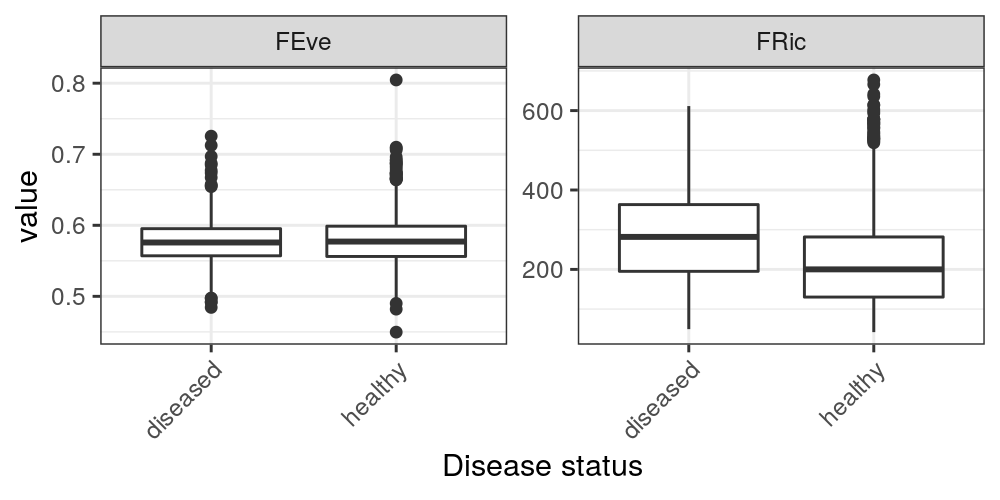

In [79]:
# plotting
func = function(x) mean(-x)
p = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    filter(!is.na(disease)) %>%
    mutate(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    mutate(disease = disease %>% reorder(value, func)) %>%
    ggplot(aes(disease, value)) +
    geom_boxplot() +
    labs(x='Disease status') +
    facet_wrap(~ measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=45, hjust=1)
    )

p.dims(5,2.5)
plot(p)

In [142]:
# calculating effect size
cohen_d = function(df){
    res = effsize::cohen.d(scales::rescale(df$value), 
                           df$disease)

    res = data.frame(estimate = res$estimate,
                     ci_lower = res$conf.int[1],
                     ci_upper = res$conf.int[2],
                     measure = df$measure[1],
                     n = nrow(df))
    return(res)
}

cd_res = FD_res_df_f %>%
    filter(measure %in% c('FEve', 'FRic')) %>%
    filter(!is.na(disease)) %>%
    mutate(disease = ifelse(disease != 'healthy', 'diseased', disease),
           disease = disease %>% factor(levels=c('healthy', 'diseased'))) %>%
    arrange(disease) %>%
    group_split(measure) %>%
    lapply(cohen_d) %>%
    rbindlist(use.names=TRUE) 
cd_res

estimate,ci_lower,ci_upper,measure,n
<dbl>,<dbl>,<dbl>,<chr>,<int>
0.06846208,-0.01940353,0.1563277,FEve,2755
-0.57705855,-0.66621828,-0.4878988,FRic,2755


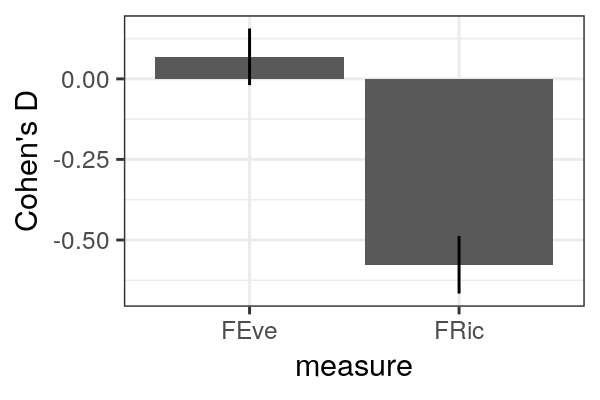

In [143]:
# plotting
p = cd_res %>%
    ggplot(aes(measure, estimate)) +
    geom_bar(stat='identity') +
    geom_linerange(aes(ymin=ci_lower,
                       ymax=ci_upper)) +
    labs(y='Cohen\'s D') +
    theme_bw()
p.dims(3,2)
plot(p)

### Mixed effects models

* How does function vary with host phenotype (random effect = study)?

In [37]:
library(lme4)
library(lmerTest)

Loading required package: Matrix


Attaching package: ‘Matrix’


The following objects are masked from ‘package:tidyr’:

    expand, pack, unpack


Registered S3 methods overwritten by 'lme4':
  method                          from
  cooks.distance.influence.merMod car 
  influence.merMod                car 
  dfbeta.influence.merMod         car 
  dfbetas.influence.merMod        car 


Attaching package: ‘lmerTest’


The following object is masked from ‘package:lme4’:

    lmer


The following object is masked from ‘package:stats’:

    step




In [38]:
lmer_res = list()

#### Full dataset

In [39]:
fm = FD_res_df_f %>%
    filter(measure == 'FRic') %>%
    lmer(value ~ westernized + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['full_FRic']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + (1 | dataset_name)
   Data: .

REML criterion at convergence: 39899.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.8728 -0.6899 -0.0988  0.6098  3.8298 

Random effects:
 Groups       Name        Variance Std.Dev.
 dataset_name (Intercept) 5064     71.16   
 Residual                 8508     92.24   
Number of obs: 3348, groups:  dataset_name, 33

Fixed effects:
                Estimate Std. Error     df t value Pr(>|t|)    
(Intercept)       255.43      16.68  70.18  15.312   <2e-16 ***
westernizedTRUE   -13.38      14.19 642.49  -0.943    0.346    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
wstrnzdTRUE -0.648

In [40]:
fm = FD_res_df_f %>%
    filter(measure == 'FEve') %>%
    lmer(value ~ westernized + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['full_FEve']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + (1 | dataset_name)
   Data: .

REML criterion at convergence: -14387.9

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.5295 -0.6304 -0.0279  0.5768  8.0696 

Random effects:
 Groups       Name        Variance  Std.Dev.
 dataset_name (Intercept) 0.0001393 0.0118  
 Residual                 0.0007730 0.0278  
Number of obs: 3348, groups:  dataset_name, 33

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)       0.599657   0.003509  58.319637 170.911  < 2e-16 ***
westernizedTRUE  -0.018115   0.003589 129.562868  -5.047 1.48e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
wstrnzdTRUE -0.779

#### Westernized + gender

In [41]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           measure == 'FRic') %>%
    lmer(value ~ westernized + gender + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g_FRic']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + (1 | dataset_name)
   Data: .

REML criterion at convergence: 25456.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0116 -0.6724 -0.0808  0.6325  3.7551 

Random effects:
 Groups       Name        Variance Std.Dev.
 dataset_name (Intercept) 2425     49.25   
 Residual                 7816     88.41   
Number of obs: 2154, groups:  dataset_name, 19

Fixed effects:
                Estimate Std. Error      df t value Pr(>|t|)    
(Intercept)       275.96      21.44   27.93  12.869 2.92e-13 ***
westernizedTRUE   -59.62      23.23   37.70  -2.566   0.0144 *  
gendermale          1.01       4.31 2150.84   0.234   0.8147    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) wsTRUE
wstrnzdTRUE -0.829       
gendermale  -0.064 -0.026

In [42]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           measure == 'FEve') %>%
    lmer(value ~ westernized + gender + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g_FEve']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + (1 | dataset_name)
   Data: .

REML criterion at convergence: -9405.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.7016 -0.6270 -0.0146  0.5625  8.3789 

Random effects:
 Groups       Name        Variance  Std.Dev.
 dataset_name (Intercept) 0.0001425 0.01194 
 Residual                 0.0007170 0.02678 
Number of obs: 2154, groups:  dataset_name, 19

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      6.038e-01  5.528e-03  2.371e+01 109.230  < 2e-16 ***
westernizedTRUE -2.611e-02  6.097e-03  2.833e+01  -4.282 0.000192 ***
gendermale      -2.165e-04  1.303e-03  2.150e+03  -0.166 0.868078    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) wsTRUE
wstrnzdTRUE -0.842       
gendermale  -0.083 -0.019

#### westernized + gender + age

In [43]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           !is.na(age),
           measure == 'FRic') %>%
    mutate(age = log2(age)) %>%
    lmer(value ~ westernized + gender + age + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a_FRic']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + (1 | dataset_name)
   Data: .

REML criterion at convergence: 21836.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.9524 -0.6608 -0.0970  0.6162  3.6865 

Random effects:
 Groups       Name        Variance Std.Dev.
 dataset_name (Intercept) 2486     49.86   
 Residual                 8080     89.89   
Number of obs: 1843, groups:  dataset_name, 17

Fixed effects:
                Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)      275.401     36.266  143.145   7.594 3.67e-12 ***
westernizedTRUE  -57.670     23.765   34.101  -2.427   0.0207 *  
gendermale        -1.017      4.819 1838.721  -0.211   0.8329    
age                0.368      5.454 1530.645   0.067   0.9462    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) wsTRUE gndrml
wstrnzdTRUE -0.488     

In [44]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           !is.na(age),
           measure == 'FEve') %>%
    mutate(age = log2(age)) %>%
    lmer(value ~ westernized + gender + age + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a_FEve']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + (1 | dataset_name)
   Data: .

REML criterion at convergence: -7986.8

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.6682 -0.6419  0.0004  0.5582  7.7853 

Random effects:
 Groups       Name        Variance  Std.Dev.
 dataset_name (Intercept) 0.0001681 0.01297 
 Residual                 0.0007335 0.02708 
Number of obs: 1843, groups:  dataset_name, 17

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      5.789e-01  1.048e-02  1.652e+02  55.244  < 2e-16 ***
westernizedTRUE -2.466e-02  6.523e-03  3.101e+01  -3.780 0.000671 ***
gendermale      -1.369e-04  1.450e-03  1.839e+03  -0.094 0.924792    
age              4.726e-03  1.631e-03  1.365e+03   2.898 0.003815 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) wsTRUE gndrml


#### westernized + gender + age + bmi

In [55]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           !is.na(age),
           !is.na(BMI),
           measure == 'FRic') %>%
    mutate(age = log2(age),
           BMI = car::bcPower(BMI, -1)) %>%
    lmer(value ~ westernized + gender + age + BMI + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a-b_FRic']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + BMI + (1 | dataset_name)
   Data: .

REML criterion at convergence: 10972.7

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.1033 -0.6778 -0.1257  0.6595  3.2603 

Random effects:
 Groups       Name        Variance Std.Dev.
 dataset_name (Intercept) 3021     54.96   
 Residual                 7413     86.10   
Number of obs: 935, groups:  dataset_name, 11

Fixed effects:
                Estimate Std. Error       df t value Pr(>|t|)  
(Intercept)     -698.240    476.203  926.131  -1.466   0.1429  
westernizedTRUE  -41.026     31.197   41.523  -1.315   0.1957  
gendermale         3.304      5.780  926.011   0.572   0.5677  
age               -9.789      6.666  898.079  -1.468   0.1423  
BMI             1059.009    499.923  929.997   2.118   0.0344 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effect

In [56]:
fm = FD_res_df_f %>%
    filter(!is.na(gender),
           !is.na(age),
           !is.na(BMI),
           measure == 'FEve') %>%
    mutate(age = log2(age),
           BMI = car::bcPower(BMI, -1)) %>%
    lmer(value ~ westernized + gender + age + BMI + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a-b_FEve']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + BMI + (1 | dataset_name)
   Data: .

REML criterion at convergence: -3995.1

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.7674 -0.6415 -0.0220  0.5616  7.6114 

Random effects:
 Groups       Name        Variance  Std.Dev.
 dataset_name (Intercept) 0.0002377 0.01542 
 Residual                 0.0007610 0.02759 
Number of obs: 935, groups:  dataset_name, 11

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      6.926e-01  1.522e-01  9.229e+02   4.549  6.1e-06 ***
westernizedTRUE -2.218e-02  9.381e-03  3.400e+01  -2.365   0.0239 *  
gendermale       2.206e-04  1.851e-03  9.269e+02   0.119   0.9052    
age              5.336e-03  2.127e-03  8.691e+02   2.508   0.0123 *  
BMI             -1.237e-01  1.600e-01  9.294e+02  -0.773   0.4396    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’

#### westernized + gender + age + disease

In [57]:
fm = FD_res_df_f %>%
    mutate(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    filter(!is.na(gender),
           !is.na(age),
           !is.na(disease),
           measure == 'FRic') %>%
    mutate(age = log2(age),
           BMI = car::bcPower(BMI, -1)) %>%
    lmer(value ~ westernized + gender + age + disease + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a-d_FRic']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + disease + (1 | dataset_name)
   Data: .

REML criterion at convergence: 16596.2

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-3.0339 -0.6647 -0.1379  0.6218  3.8483 

Random effects:
 Groups       Name        Variance Std.Dev.
 dataset_name (Intercept) 2929     54.12   
 Residual                 7331     85.62   
Number of obs: 1413, groups:  dataset_name, 15

Fixed effects:
                Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)      372.382     41.416  178.472   8.991 3.50e-16 ***
westernizedTRUE  -54.614     26.254   45.702  -2.080   0.0431 *  
gendermale        -7.750      4.902 1407.931  -1.581   0.1141    
age               -5.720      5.862 1260.448  -0.976   0.3294    
diseasehealthy   -83.531     11.582  834.782  -7.212 1.24e-12 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlatio

In [58]:
fm = FD_res_df_f %>%
    mutate(disease = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    filter(!is.na(gender),
           !is.na(age),
           !is.na(disease),
           measure == 'FEve') %>%
    mutate(age = log2(age),
           BMI = car::bcPower(BMI, -1)) %>%
    lmer(value ~ westernized + gender + age + disease + (1 | dataset_name), data=.) 

summary(fm)
lmer_res[['w-g-a-d_FEve']] = anova(fm, type='II')

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: value ~ westernized + gender + age + disease + (1 | dataset_name)
   Data: .

REML criterion at convergence: -6063

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-4.6000 -0.6453 -0.0038  0.5593  7.6670 

Random effects:
 Groups       Name        Variance  Std.Dev.
 dataset_name (Intercept) 0.0001959 0.01400 
 Residual                 0.0007545 0.02747 
Number of obs: 1413, groups:  dataset_name, 15

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)    
(Intercept)      5.803e-01  1.265e-02  2.112e+02  45.875  < 2e-16 ***
westernizedTRUE -2.609e-02  7.513e-03  3.339e+01  -3.472  0.00145 ** 
gendermale       4.859e-05  1.569e-03  1.407e+03   0.031  0.97530    
age              4.865e-03  1.862e-03  1.107e+03   2.613  0.00910 ** 
diseasehealthy  -2.496e-04  3.640e-03  6.096e+02  -0.069  0.94535    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 

#### Summary: w/ BMI

In [59]:
lmer_res %>%
    lapply(function(x) tibble::rownames_to_column(x, 'variable')) %>%
    data.table::rbindlist(use.names=TRUE, idcol='hypothesis') %>%
    separate(hypothesis, c('dataset', 'metric'), sep='_') %>%
    rename('P' = `Pr(>F)`) 

dataset,metric,variable,Sum Sq,Mean Sq,NumDF,DenDF,F value,P
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
full,FRic,westernized,7.567918e+03,7.567918e+03,1,642.4857,0.8894712,3.459751e-01
full,FEve,westernized,1.969169e-02,1.969169e-02,1,129.5629,25.4757419,1.483447e-06
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
w-g-a-d,FEve,age,5.151354e-03,5.151354e-03,1,1107.0143,6.827919011,0.009096019
w-g-a-d,FEve,disease,3.547809e-06,3.547809e-06,1,609.5994,0.004702483,0.945350684


In [60]:
# to data.frame
lmer_res_f = lmer_res %>%
    lapply(function(x) tibble::rownames_to_column(x, 'variable')) %>%
    data.table::rbindlist(use.names=TRUE, idcol='hypothesis') %>%
    separate(hypothesis, c('dataset', 'metric'), sep='_') %>%
    rename('P' = `Pr(>F)`) %>%
    filter(dataset != 'w-g',
           dataset != 'w-g-a-d') %>%
    mutate(dataset = case_when(dataset == 'full' ~ '~ westernized +\n(1 | dataset)',
                               dataset == 'w-g-a' ~ '~ westernized +\nage + gender (1 | dataset)',
                               dataset == 'w-g-a-b' ~ '~ westernized +\nage+ gender + BMI (1 | dataset)')) %>%
    group_by(dataset, variable) %>%
    mutate(q_val = p.adjust(as.Num(P), method='BH'),
           .groups='drop')
lmer_res_f

dataset,metric,variable,Sum Sq,Mean Sq,NumDF,DenDF,F value,P,q_val,.groups
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
~ westernized + (1 | dataset),FRic,westernized,7.567918e+03,7.567918e+03,1,642.4857,0.8894712,3.459751e-01,3.459751e-01,drop
~ westernized + (1 | dataset),FEve,westernized,1.969169e-02,1.969169e-02,1,129.5629,25.4757419,1.483447e-06,2.966894e-06,drop
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
~ westernized + age+ gender + BMI (1 | dataset),FEve,age,0.0047886289,0.0047886289,1,869.0916,6.2923717,0.01230699,0.02461397,drop
~ westernized + age+ gender + BMI (1 | dataset),FEve,BMI,0.0004549617,0.0004549617,1,929.4232,0.5978304,0.43960363,0.43960363,drop


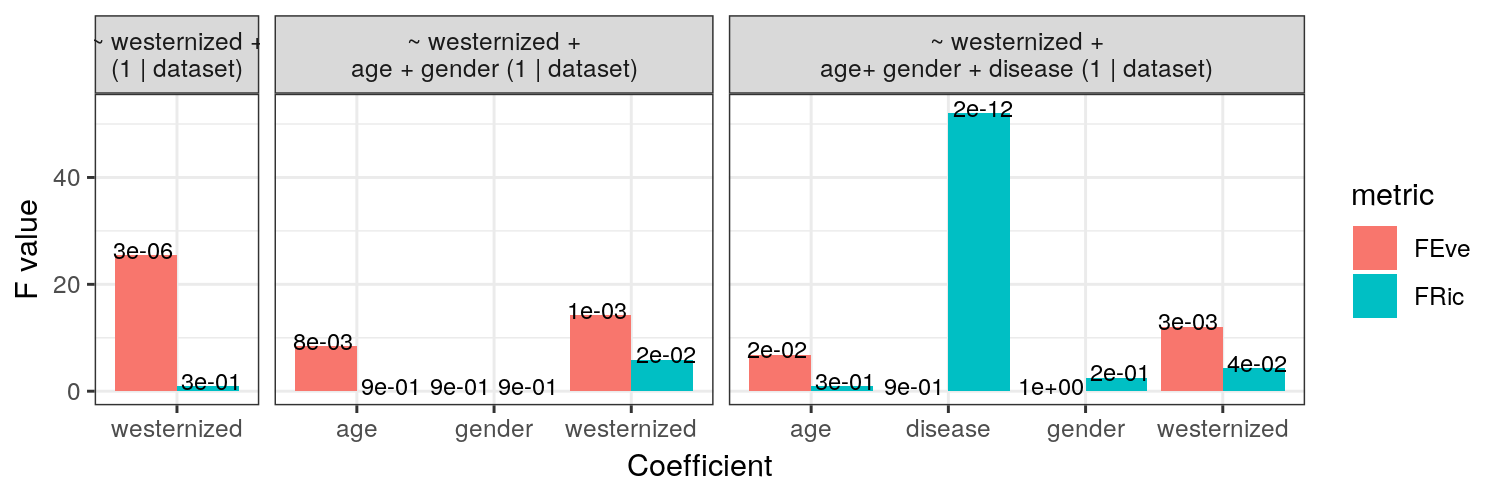

In [69]:
# plotting
p = lmer_res_f %>%
    mutate(q_val = formatC(q_val, format = "e", digits = 0)) %>%
    ggplot(aes(variable, `F value`, fill=metric)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(y = `F value` + 1, label=q_val), 
              position = position_dodge(width = 1),
              size=3) +
    facet_grid(. ~ dataset, scales='free_x', space='free_x') +
    labs(x='Coefficient') +
    theme_bw() 

p.dims(7.5,2.5)
plot(p)

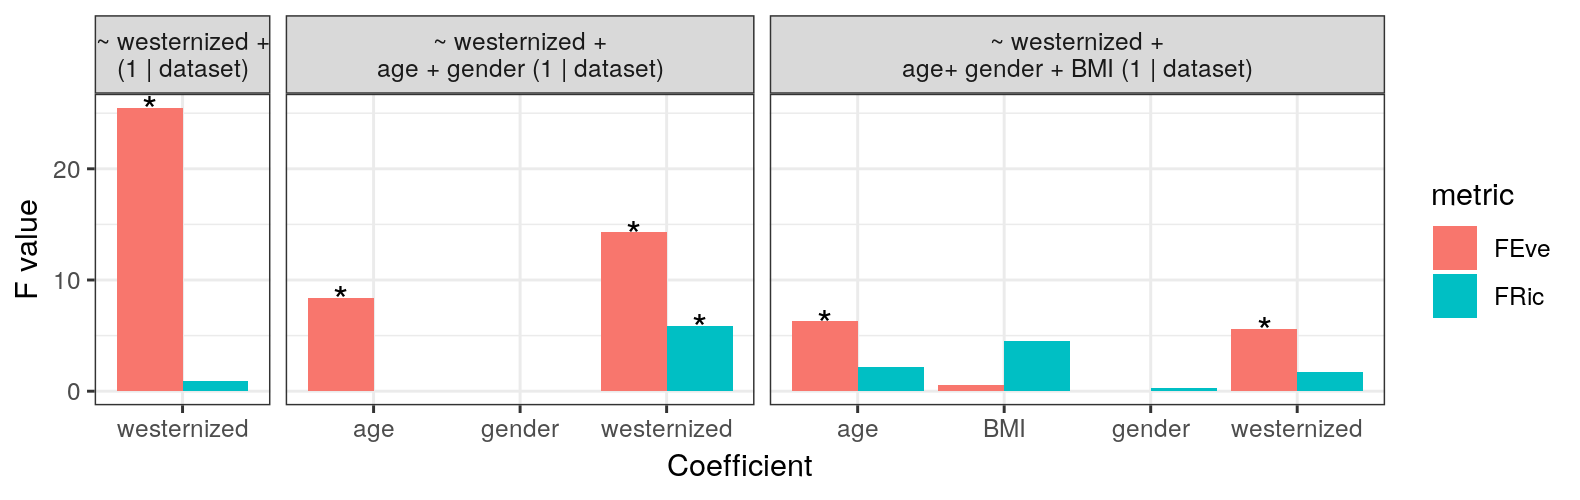

In [62]:
# plotting
p = lmer_res_f %>%
    mutate(sig = ifelse(q_val < 0.05, '*', '')) %>%
    ggplot(aes(variable, `F value`, fill=metric)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label=sig), size=5, vjust=0.6,
                  position=position_dodge(width=0.9)) +
    facet_grid(. ~ dataset, scales='free_x', space='free_x') +
    labs(x='Coefficient') +
    theme_bw() 

p.dims(7.9,2.5)
plot(p)

#### Summary: w/ disease

In [75]:
# to data.frame
lmer_res_f = lmer_res %>%
    lapply(function(x) tibble::rownames_to_column(x, 'variable')) %>%
    data.table::rbindlist(use.names=TRUE, idcol='hypothesis') %>%
    separate(hypothesis, c('dataset', 'metric'), sep='_') %>%
    rename('P' = `Pr(>F)`) %>%
    filter(dataset != 'w-g',
           dataset != 'w-g-a-b') %>%
    mutate(dataset = case_when(dataset == 'full' ~ 'measure ~\nwesternized +\n(1 | dataset)',
                               dataset == 'w-g-a' ~ 'measure ~ westernized +\nage + gender (1 | dataset)',
                               dataset == 'w-g-a-d' ~ 'measure ~ westernized +\nage+ gender + disease (1 | dataset)')) %>%
    group_by(dataset, variable) %>%
    mutate(q_val = p.adjust(as.Num(P), method='BH'),
           .groups='drop')
lmer_res_f

dataset,metric,variable,Sum Sq,Mean Sq,NumDF,DenDF,F value,P,q_val,.groups
<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
measure ~ westernized + (1 | dataset),FRic,westernized,7.567918e+03,7.567918e+03,1,642.4857,0.8894712,3.459751e-01,3.459751e-01,drop
measure ~ westernized + (1 | dataset),FEve,westernized,1.969169e-02,1.969169e-02,1,129.5629,25.4757419,1.483447e-06,2.966894e-06,drop
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
measure ~ westernized + age+ gender + disease (1 | dataset),FEve,age,5.151354e-03,5.151354e-03,1,1107.0143,6.827919011,0.009096019,0.01819204,drop
measure ~ westernized + age+ gender + disease (1 | dataset),FEve,disease,3.547809e-06,3.547809e-06,1,609.5994,0.004702483,0.945350684,0.94535068,drop


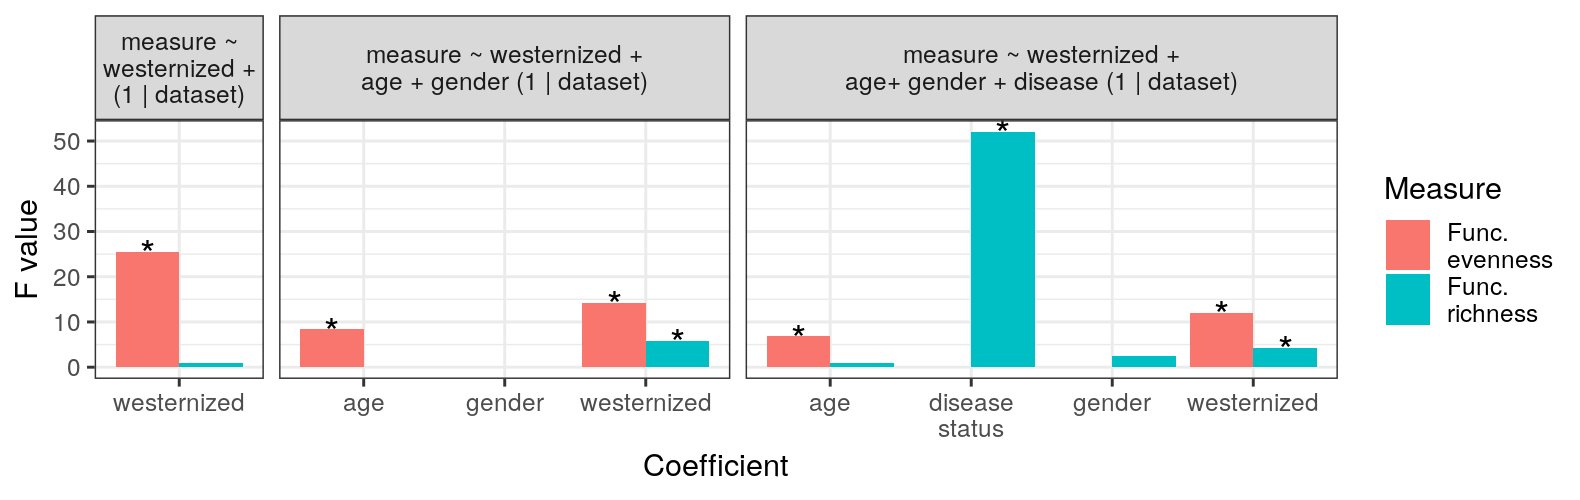

In [76]:
# plotting
p = lmer_res_f %>%
    mutate(metric = ifelse(metric == 'FEve', 'Func.\nevenness', 'Func.\nrichness')) %>%
    mutate(variable = ifelse(variable == 'disease', 'disease\nstatus', variable)) %>%
    mutate(sig = ifelse(q_val < 0.05, '*', '')) %>%
    ggplot(aes(variable, `F value`, fill=metric)) +
    geom_bar(stat='identity', position='dodge') +
    geom_text(aes(label=sig), size=5, vjust=0.6,
                  position=position_dodge(width=0.9)) +
    scale_fill_discrete('Measure') +
    facet_grid(. ~ dataset, scales='free_x', space='free_x') +
    labs(x='Coefficient') +
    theme_bw() 

p.dims(7.9,2.5)
plot(p)

## All traits

In [ ]:
# FD
## WARNING: SLOW
FD_res = dbFD(trt, m, corr="cailliez", calc.CWM=FALSE)
FD_res %>% names

Warning message in is.euclid(x.dist):
“Zero distance(s)”
Warning message in is.euclid(x.dist):
“Zero distance(s)”


FRic: Dimensionality reduction was required. The last 55 PCoA axes (out of 67 in total) were removed. 


Warning message in is.euclid(x.dist):
“Zero distance(s)”


FRic: Quality of the reduced-space representation = 0.5787986 


Warning message in is.euclid(x.dist):
“Zero distance(s)”
Warning message in is.euclid(x.dist):
“Zero distance(s)”


### Saving

In [ ]:
# saving: outfile
outfile = file.path(work_dir, 'Traitar_FD_all-trt.RDS')
outfile

In [ ]:
# saving: save
saveRDS(FD_res, outfile)
cat('File written:', outfile, '\n')

In [ ]:
# saving: re-loading
FD_res = readRDS(outfile)
FD_res %>% names

In [ ]:
send_email('http://127.0.0.1:9701/notebooks/ipynb/02_comm_diversity/10_func-div.ipynb')

# sessionInfo

In [62]:
sessionInfo()

R version 3.6.3 (2020-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 18.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ebio/abt3_projects/Georg_animal_feces/envs/function/lib/libopenblasp-r0.3.10.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lmerTest_3.1-3    lme4_1.1-25       Matrix_1.2-18     LeyLabRMisc_0.1.6
 [5] FD_1.0-12         vegan_2.5-6       lattice_0.20-41   permute_0.9-5    
 [9] geometry_0.4.5    ade4_1.7-15       ape_5.4-1         tidytable_0.5.6  
[13] data.table_1.13.2 ggplot2_3.3.2     tidyr_1.1.2    